In [ ]:
import torch
import torch.nn as nn
import numpy as np
import argparse
import os
from einops import rearrange
from einops.layers.torch import Rearrange
from scipy.io import loadmat, savemat
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset

from libs.positional_encoding_module import GaussianFourierFeatureTransform
from libs.factorization_module import FABlock2D
from libs.basics import PreNorm, MLP
from utils import dict2namespace
import yaml
import warnings
warnings.filterwarnings('ignore')

torch.backends.cudnn.benchmark = True
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [70]:
class FactorizedTransformer(nn.Module):
    def __init__(self,
                 dim,
                 dim_head,
                 heads,
                 dim_out,
                 depth,
                 n_layer,
                 **kwargs):
        super().__init__()
        self.layers = nn.ModuleList([])
        for _ in range(depth):

            layer = nn.ModuleList([])
            layer.append(nn.Sequential(
                GaussianFourierFeatureTransform(2, dim // 2, 8),
                nn.Linear(dim, dim)
            ))
            layer.append(FABlock2D(dim, dim_head, dim, heads, dim_out, use_rope=True, **kwargs))
            self.layers.append(layer)
            
        self.n_layer = n_layer

    def forward(self, u, pos_lst):
        b, nx, ny, c = u.shape
        nx, ny = pos_lst[0].shape[0], pos_lst[1].shape[0]
        pos = torch.stack(torch.meshgrid([pos_lst[0].squeeze(-1), pos_lst[1].squeeze(-1)]), dim=-1)
        for pos_enc, attn_layer in self.layers:
            u += pos_enc(pos).view(1, nx, ny, -1)
            for i in range(self.n_layer):
                u = u + attn_layer(u, pos_lst) / self.n_layer
        return u


class FactFormer2D(nn.Module):
    def __init__(self,
                 config
                 ):
        super().__init__()
        self.config = config
        # self.resolutions = config.resolutions   # hierachical resolutions, [16, 8, 4]
        # self.out_resolution = config.out_resolution

        self.in_dim = config.in_dim
        self.in_tw = config.in_time_window
        self.out_dim = config.out_dim
        self.out_tw = config.out_time_window

        self.dim = config.dim                 # dimension of the transformer
        self.depth = config.depth           # depth of the encoder transformer
        self.dim_head = config.dim_head

        self.heads = config.heads

        self.pos_in_dim = config.pos_in_dim
        self.pos_out_dim = config.pos_out_dim
        
        self.kernel_multiplier = config.kernel_multiplier
        self.latent_multiplier = config.latent_multiplier
        self.latent_dim = int(self.dim * self.latent_multiplier)
        self.max_latent_steps = config.max_latent_steps
        
        self.n_layer = config.n_layer

        # flatten time window
        self.to_in = nn.Linear(self.in_tw*self.in_dim, self.dim, bias=True)

        # assume input is b c t h w d
        self.encoder = FactorizedTransformer(self.dim, self.dim_head, self.heads, self.dim, self.depth, self.n_layer,
                                             kernel_multiplier=self.kernel_multiplier)
        self.expand_latent = nn.Linear(self.dim, self.latent_dim, bias=False)
        self.latent_time_emb = nn.Parameter(torch.randn(1, self.max_latent_steps,
                                                        1, 1, self.latent_dim) * 0.02,
                                            requires_grad=True)

        self.propagator = PreNorm(self.latent_dim,
                                  MLP([self.latent_dim, self.dim, self.latent_dim], act_fn=nn.GELU()))
        self.simple_to_out = nn.Sequential(
            Rearrange('b nx ny c -> b c (nx ny)'),
            nn.GroupNorm(num_groups=int(8 * self.latent_multiplier), num_channels=self.latent_dim),
            nn.Conv1d(self.latent_dim, self.dim, kernel_size=1, stride=1, padding=0,
                      groups=8, bias=False),
            nn.GELU(),
            nn.Conv1d(self.dim, self.dim // 2, kernel_size=1, stride=1, padding=0, bias=False),
            nn.GELU(),
            nn.Conv1d(self.dim // 2, self.out_dim, kernel_size=1, stride=1, padding=0, bias=True)
        )

    def forward(self,
                u,
                pos_lst,
                latent_steps=1,
                use_mask=False 
                ):
        
        if use_mask:
            mask = u[:, [-1], ...]
            u = u[:, :-1, ...]
            u = u * (torch.ones_like(mask) - mask)
        
        b, c, t, nx, ny = u.shape
        u = rearrange(u, 'b c t nx ny -> b nx ny (c t)')
        u = self.to_in(u)
        u = self.encoder(u, pos_lst)
        u_lst = []
        u = self.expand_latent(u)
        for l_t in range(1):
            u = u + self.latent_time_emb[:, l_t, ...]
            u = self.propagator(u) + u
            u_lst.append(u)

        u = torch.cat(u_lst, dim=0)
        u = self.simple_to_out(u)
        u = rearrange(u, '(t b) c (nx ny) -> b t nx ny c', nx=nx, ny=ny, t=1)
        return u


In [71]:
def set_random_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def inference(save_dirs, model_dirs, latent_steps, infer_steps, config, args, use_mask):
    assert latent_steps <= config.model.max_latent_steps

    device = torch.device('cuda' if torch.cuda.is_available() and args.device == 'cuda' else 'cpu')
    model = FactFormer2D(config.model).to(device)

    model_path = os.path.join(save_dirs, 'model', model_dirs+'.pth')
    model.load_state_dict(torch.load(f'{model_path}'))

    x = args.input_set.to(device)
    y = args.output_set

    pos_x = torch.linspace(0, 2 * np.pi, args.resolution_x).float().to(device).unsqueeze(-1)
    pos_y = torch.linspace(0, 2 * np.pi, args.resolution_y).float().to(device).unsqueeze(-1)
    pos_lst = [pos_x, pos_y]
    
    if use_mask:
        mask_y = y[..., [-1]]
        y = y[..., :-1]
        y = y * (torch.ones_like(mask_y) - mask_y)

    y_hat_list = []
    steps = 0
    while True:
        with torch.no_grad():
            y_hat = model(x, pos_lst, latent_steps, use_mask)
            y_hat = rearrange(y_hat, 'b t h w c -> b c t h w')
            y_hat = torch.cat([y_hat, mask_y], dim=-1)
            x = torch.cat([x[:, :, latent_steps:], y_hat], dim=2)
            y_hat_list.append(y_hat.cpu().numpy())
            steps += latent_steps

        if steps >= infer_steps:
            break

    y_hat = np.concatenate(y_hat_list, axis=1)
    y_hat = y_hat[:, :infer_steps, ...]
    y = y.numpy()
    y = y[:, :infer_steps, ...]


    # npy数据
    output_dir = os.path.join(save_dirs, f'npy_data')
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    np.save(os.path.join(output_dir, 'y.npy'), y)
    np.save(os.path.join(output_dir, 'y_hat.npy'), y_hat)

    MSE_time = np.mean((y_hat - y) ** 2, axis=(0, 2, 3, 4)) / np.mean(y ** 2, axis=(0, 2, 3, 4))
    print(f'MSE_time:{MSE_time}')
    np.save(os.path.join(output_dir, 'MSE_time.npy'), MSE_time)

In [ ]:
class Options():
    def __init__(self):
        parser = argparse.ArgumentParser(description=globals()['__doc__'])
        parser.add_argument( '--config', type=str, default='gba_factformer2d.yml', help='Path to the config file')
        parser.add_argument('--seed', type=int, default=1234, help='Random seed')
        parser.add_argument('--resume', action='store_true', help='Resume training')
        parser.add_argument('--testing', action='store_true', help='Testing mode')
        parser.add_argument('--ckpt_to_resume', type=str, default=None, help='Checkpoint to resume')
        parser.add_argument('--comment', type=str, default='', help='Comment')
        parser.add_argument('--device', type=str, default='cuda', help='Device:cpu or cuda')
        parser.add_argument('--save_dirs', type=str, default='', help='Save dirs')
        parser.add_argument('--model_dirs', type=str, default='checkpoint_final', help='Model dirs')
        
        self.parser = parser

    def parse(self):
        args = self.parser.parse_args(args=[])

        # parse config file
        with open(os.path.join(f'configs', args.config), 'r') as f:
            config = yaml.safe_load(f)
        config = dict2namespace(config)
        return args, config

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## 数据导入

In [ ]:
args, config = Options().parse()

data_dir = Path("/data1/user/gjx/ocean_uv_forecast/data_gba_crop149x148")

uv = np.load(data_dir / "uv_daily.npy")
data = torch.from_numpy(uv).permute(0, 2, 3, 1).unsqueeze(0).float()

with np.load(data_dir / 'stats.npz') as stats:
    mean = torch.from_numpy(stats['mean_u'].astype(np.float32))
    std = torch.from_numpy(stats['std_u'].astype(np.float32))

data = (data - mean) / std # 标准化
del uv

with np.load(data_dir / "split.npz") as splits:
    bounds = {
        name: (int(splits[f'{name}_start']), int(splits[f'{name}_end'])) for name in ("train", "val", "test")
    }

b, t, nx, ny, c = data.shape
in_time_window = 7
out_time_window = 1

sets = {}
for name, (start, end) in bounds.items():
    input_list = []
    output_list = []

    sample_num = (end - start) - (in_time_window + out_time_window) + 1

    for i in range(b):
        for j in range(start, start + sample_num):
            input_list.append(data[i, j:j + in_time_window, ...])
            output_list.append(
                data[i, j + in_time_window:
                    j + in_time_window + out_time_window, ...]
            )

    input_data = torch.stack(input_list)
    output_data = torch.stack(output_list)

    input_data = rearrange(input_data, "b t h w c -> b c t h w")
    sets[name] = (input_data, output_data)

train_x, train_y = sets['train']
val_x, val_y = sets['val']
test_x, test_y = sets['test']

pos_lst = [
    torch.linspace(0, 2 * np.pi, nx, device=device).unsqueeze(-1),
    torch.linspace(0, 2 * np.pi, ny, device=device).unsqueeze(-1),
]

train_loader = DataLoader(
    TensorDataset(train_x, train_y),
    batch_size=config.training.batch_size, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(val_x, val_y),
    batch_size=config.training.batch_size, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(test_x, test_y),
    batch_size=config.training.batch_size, shuffle=False
)


(1, 31, 240, 180, 3)


In [ ]:
# ------------training------------
set_random_seed(args.seed)
model = FactFormer2D(config.model).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.training.lr)
loss_fn = nn.MSELoss()

model_dir = Path(config.log_dir) / 'model'
model_dir.mkdir(parents=True, exist_ok=True)
best_val_loss = float('inf')
history = []

for epoch in range(config.training.epochs):
    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        y_hat = model(x, pos_lst, latent_steps=1, use_mask=False)
        loss = loss_fn(y_hat, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.shape[0]
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            y_hat = model(x, pos_lst, latent_steps=1, use_mask=False)
            val_loss += loss_fn(y_hat, y).item() * x.shape[0]
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_dir / 'best.pth')
    print(f'Epoch {epoch + 1}/{config.training.epochs}  '
          f'train={train_loss:.6f}  val={val_loss:.6f}  best={best_val_loss:.6f}')

In [ ]:
# ------------inference------------
save_dirs = args.save_dirs
model_dirs = args.model_dirs
latent_steps = 1 if config.model.out_time_window==1 else config.model.max_latent_steps
# infer_steps = 200
# infer_steps = 59

In [ ]:
model = FactFormer2D(config.model).to(device)
ckpt_path = Path(config.log_dir) / 'model' / 'best.pth'  
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()

nx, ny = test_x.shape[-2:]
pos_lst = [
    torch.linspace(0, 2 * np.pi, nx, device=device).unsqueeze(-1),
    torch.linspace(0, 2 * np.pi, ny, device=device).unsqueeze(-1),
]

x = test_x[0:1].to(device)                    
infer_steps = len(test_y)
predictions = []

with torch.no_grad():
    for _ in range(infer_steps):
        y_next = model(x, pos_lst, latent_steps=1, use_mask=False)
        # y_next: [1, 1, 149, 148, 2]
        predictions.append(y_next.cpu())

        next_frame = y_next[:, 0].permute(0, 3, 1, 2).unsqueeze(2)
        # next_frame: [1, 2, 1, 149, 148]
        x = torch.cat([x[:, :, 1:], next_frame], dim=2)

y_hat = torch.cat(predictions, dim=1)        # [1, 359, 149, 148, 2]
y_gt = test_y[:, 0].unsqueeze(0)             # [1, 359, 149, 148, 2]

# 反标准化
y_hat_phys = y_hat * std.view(1, 1, 1, 1, 2) + mean.view(1, 1, 1, 1, 2)
y_gt_phys = y_gt * std.view(1, 1, 1, 1, 2) + mean.view(1, 1, 1, 1, 2)

In [ ]:
y = y_gt_phys.numpy()
y_hat = y_hat_phys.numpy()

0


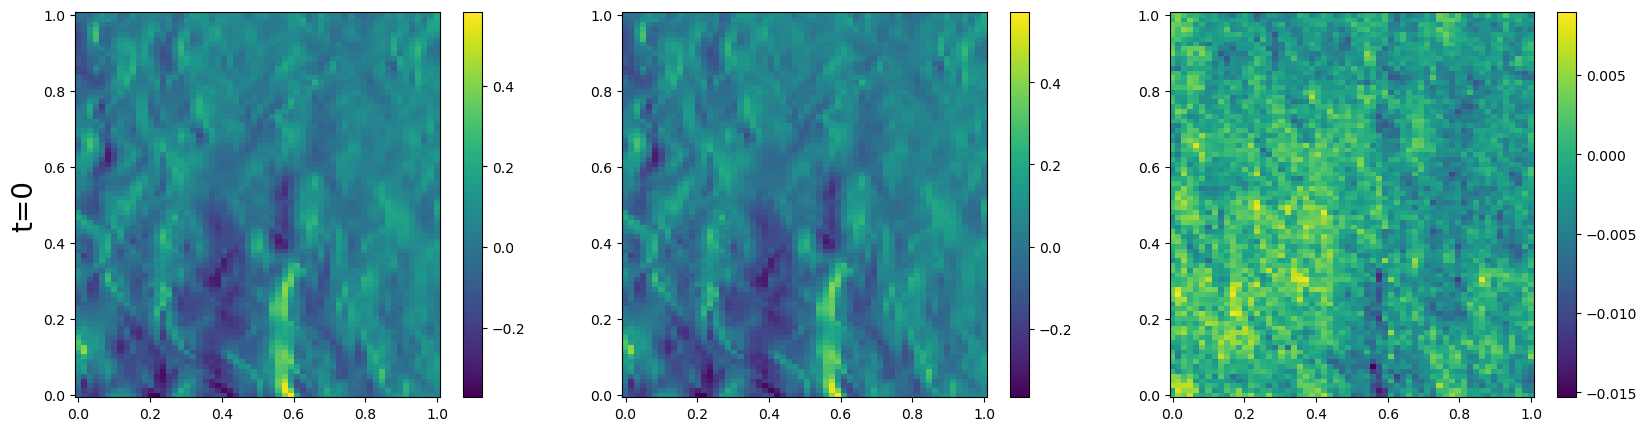

Relative l2 error of u: 3.001e-02
1


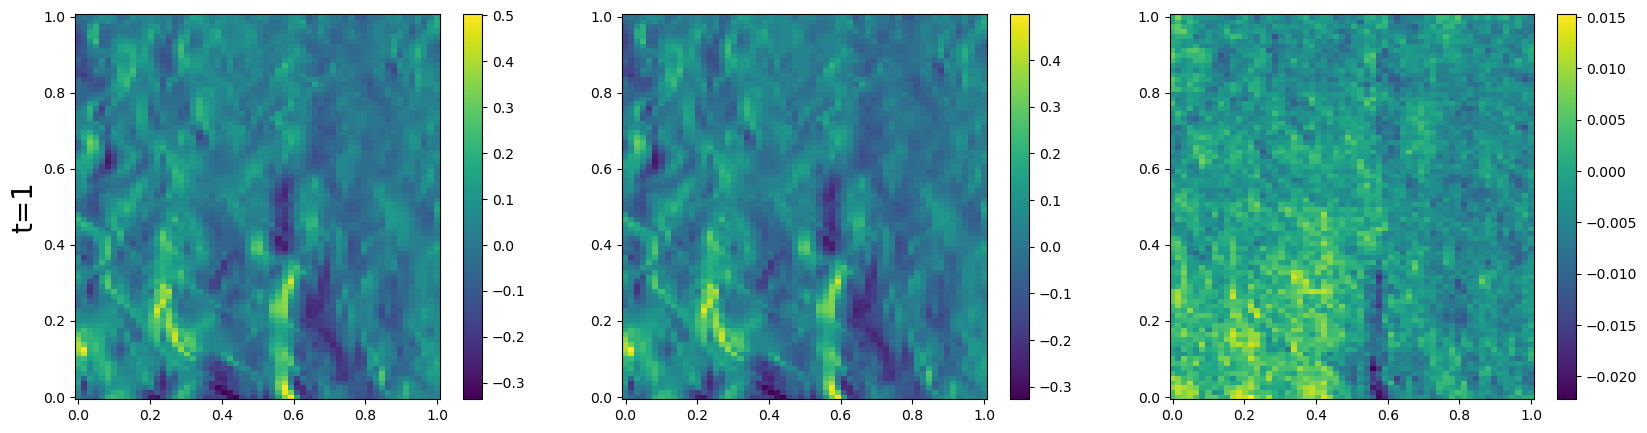

Relative l2 error of u: 4.625e-02
2


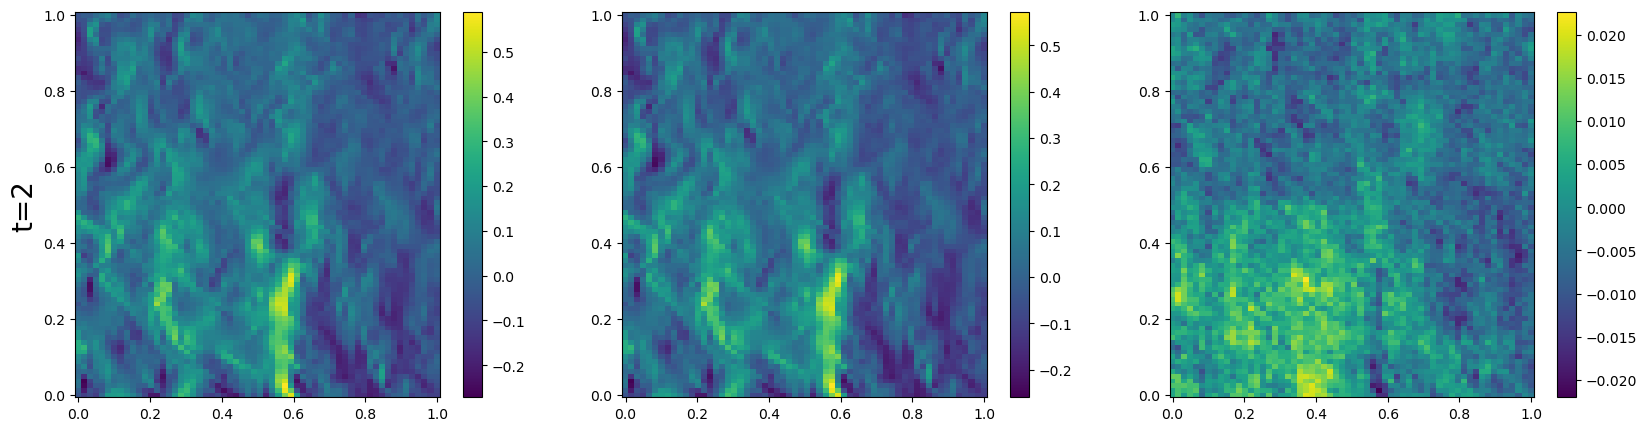

Relative l2 error of u: 5.914e-02
3


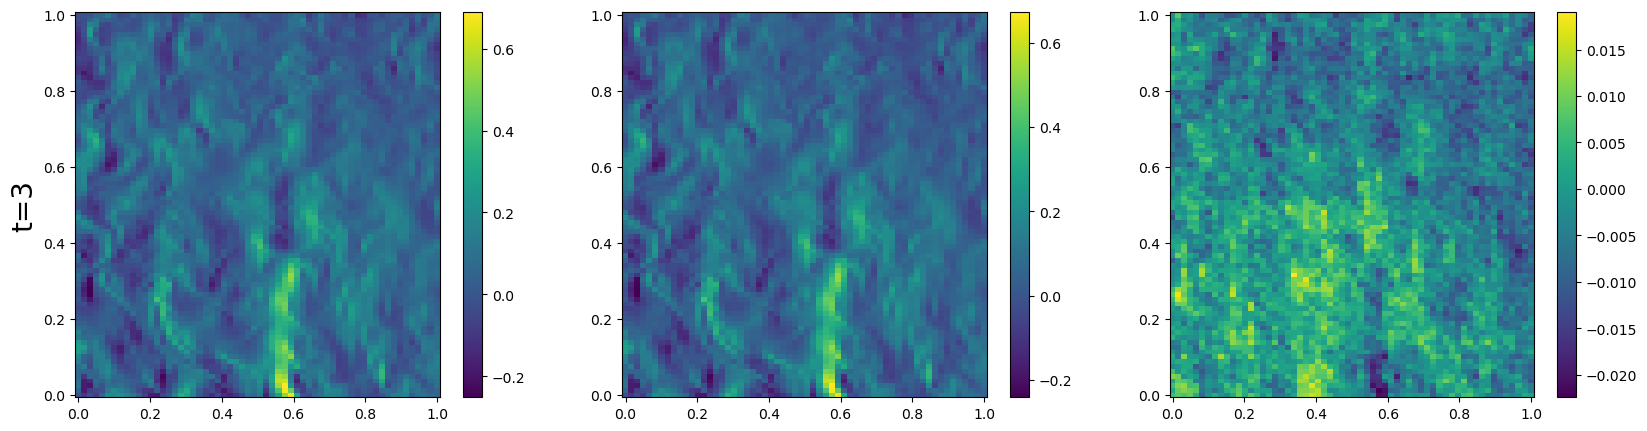

Relative l2 error of u: 5.423e-02
4


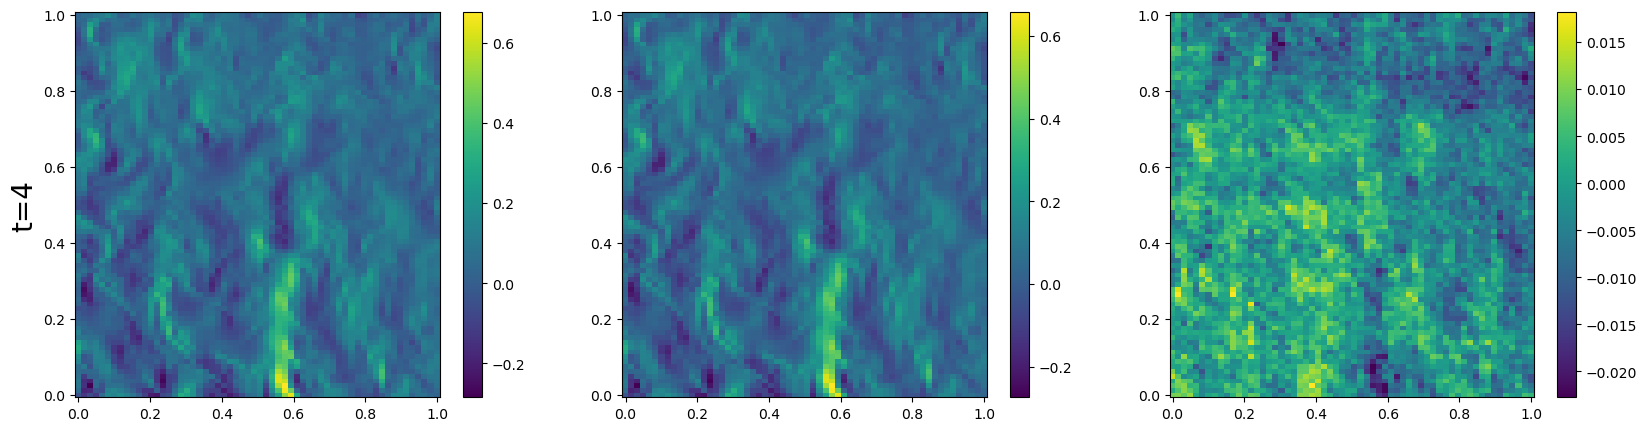

Relative l2 error of u: 5.775e-02
5


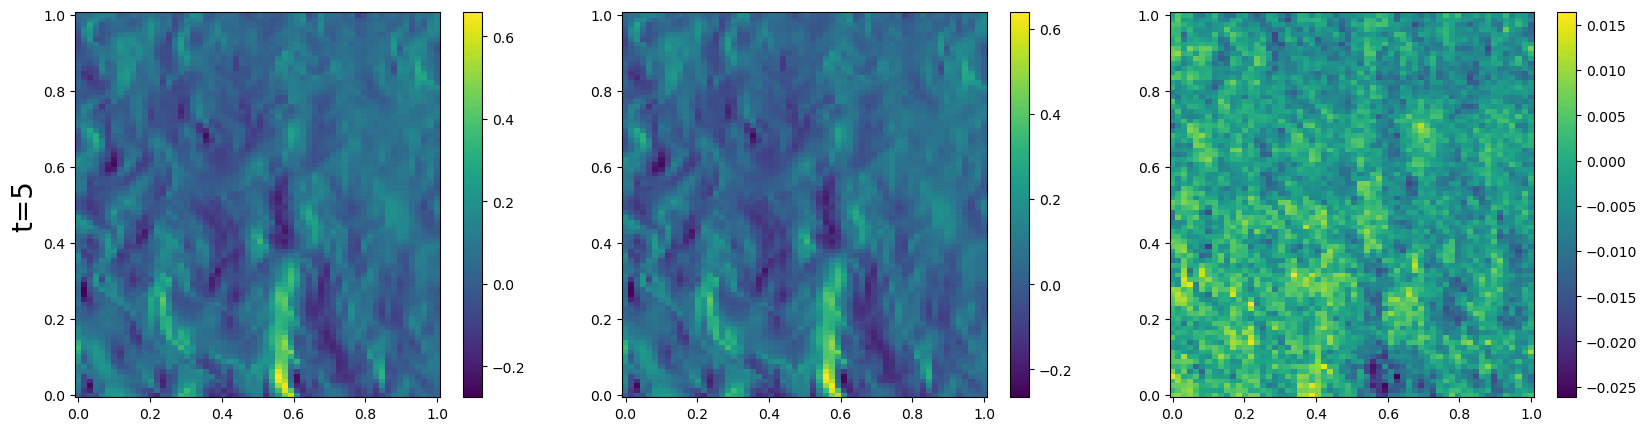

Relative l2 error of u: 5.377e-02
6


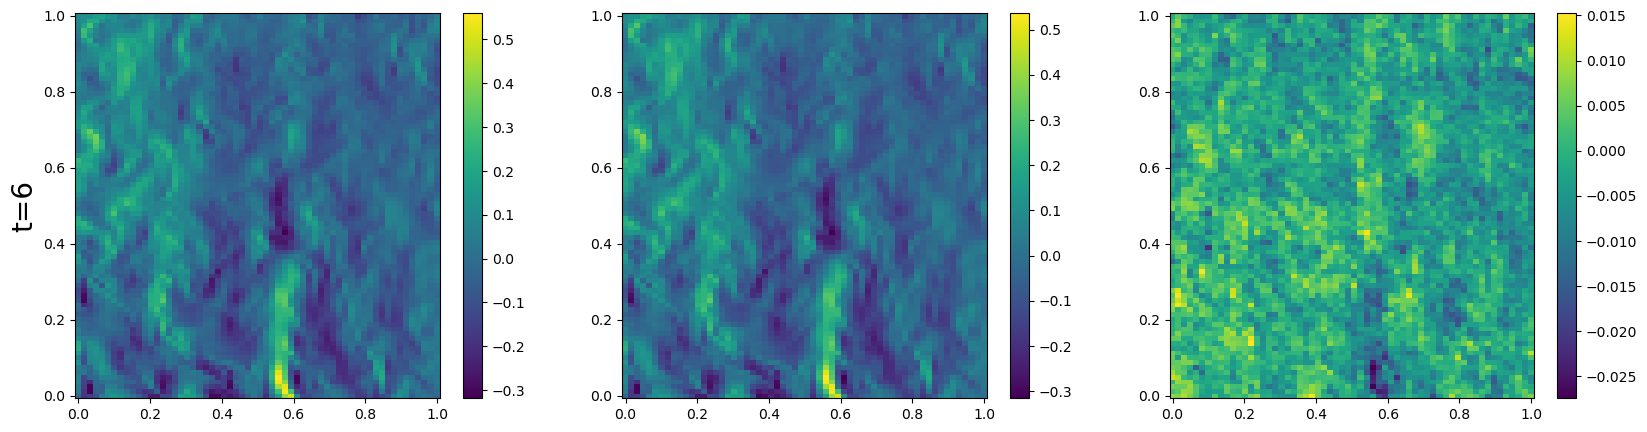

Relative l2 error of u: 5.487e-02
7


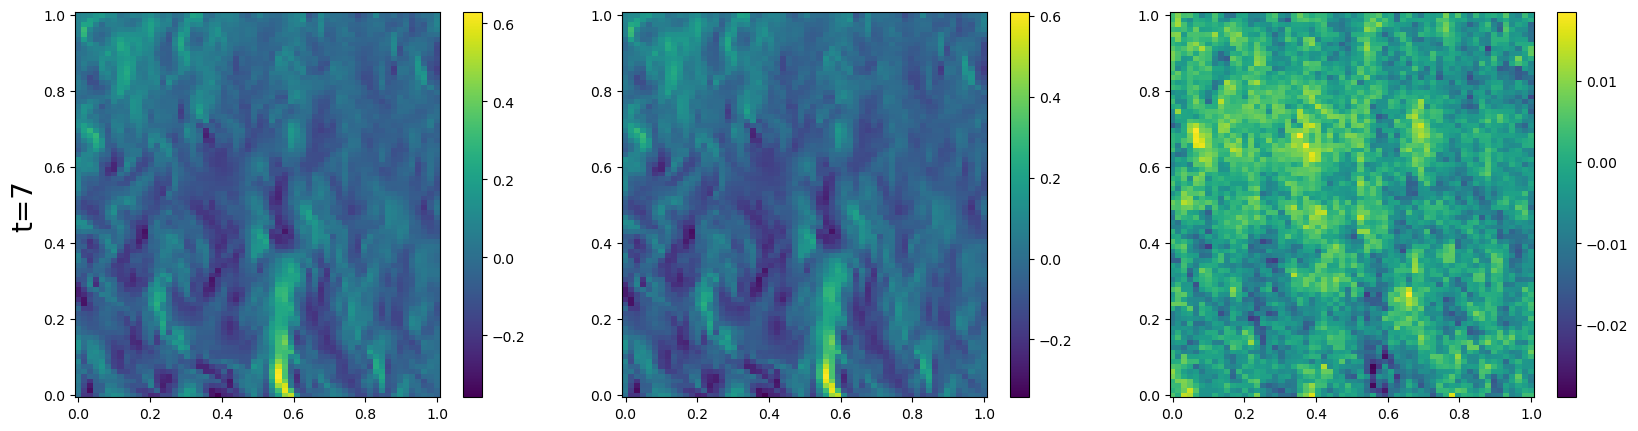

Relative l2 error of u: 6.189e-02
8


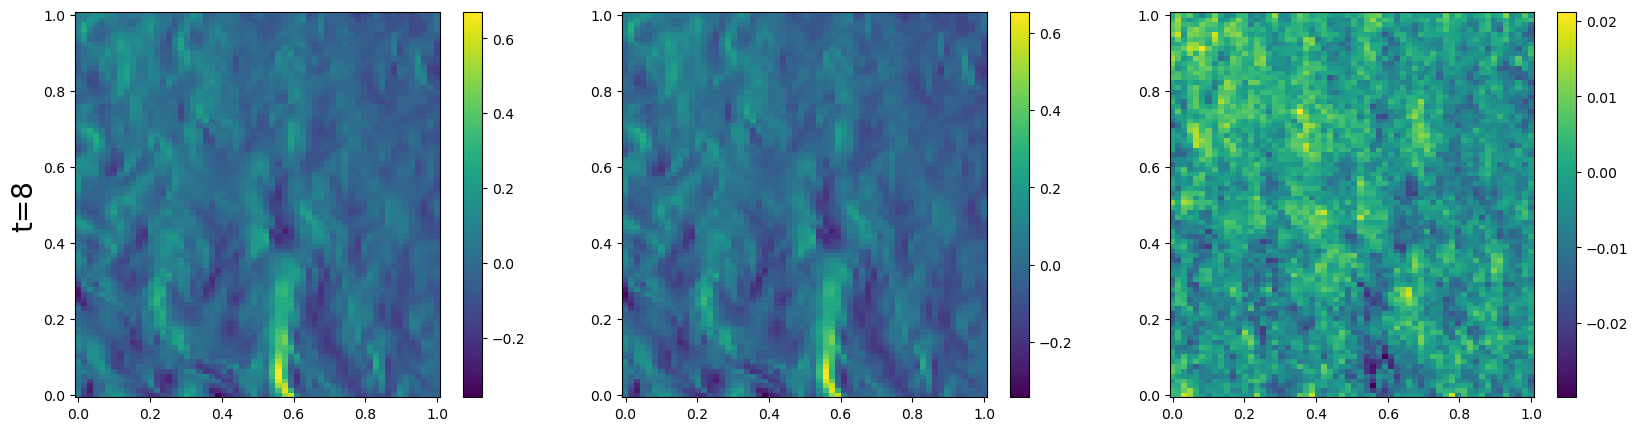

Relative l2 error of u: 7.288e-02
9


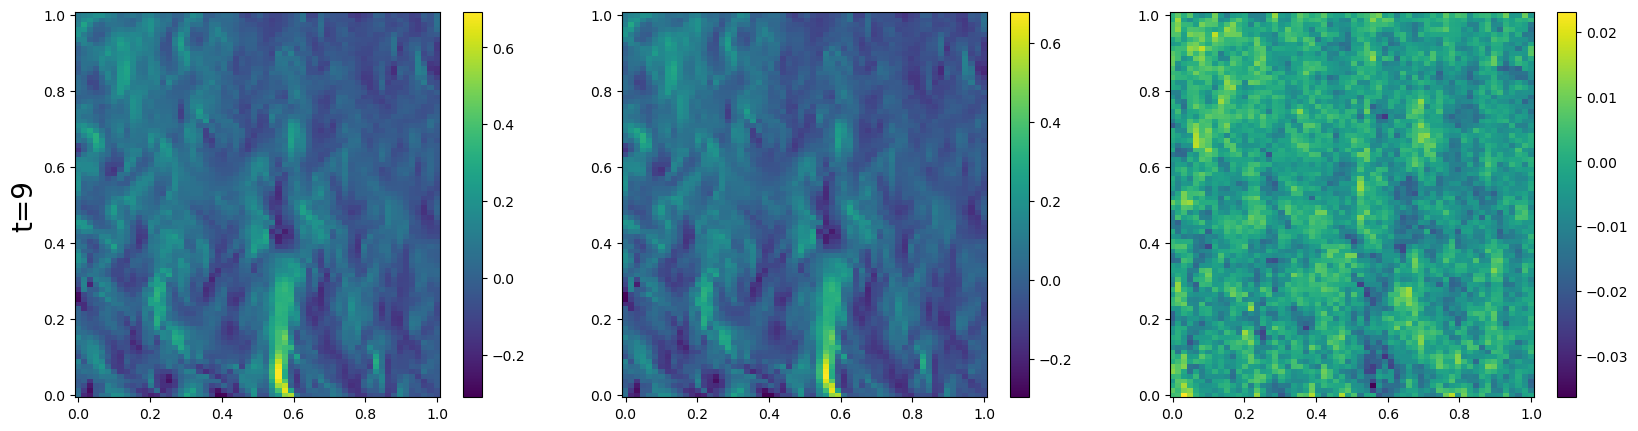

Relative l2 error of u: 7.098e-02
10


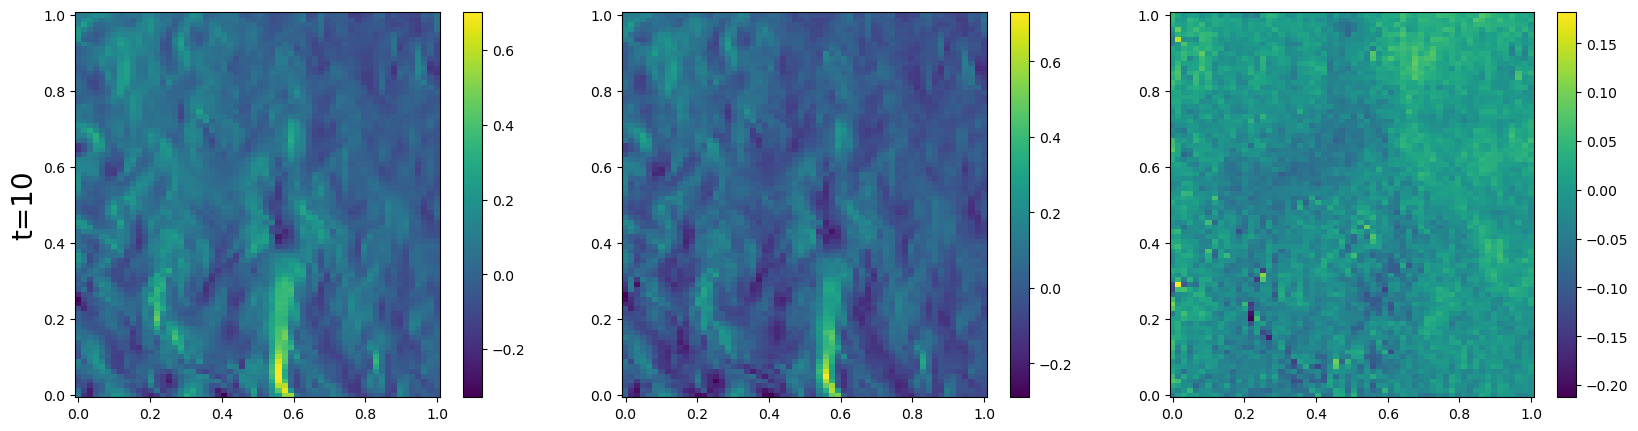

Relative l2 error of u: 3.329e-01
11


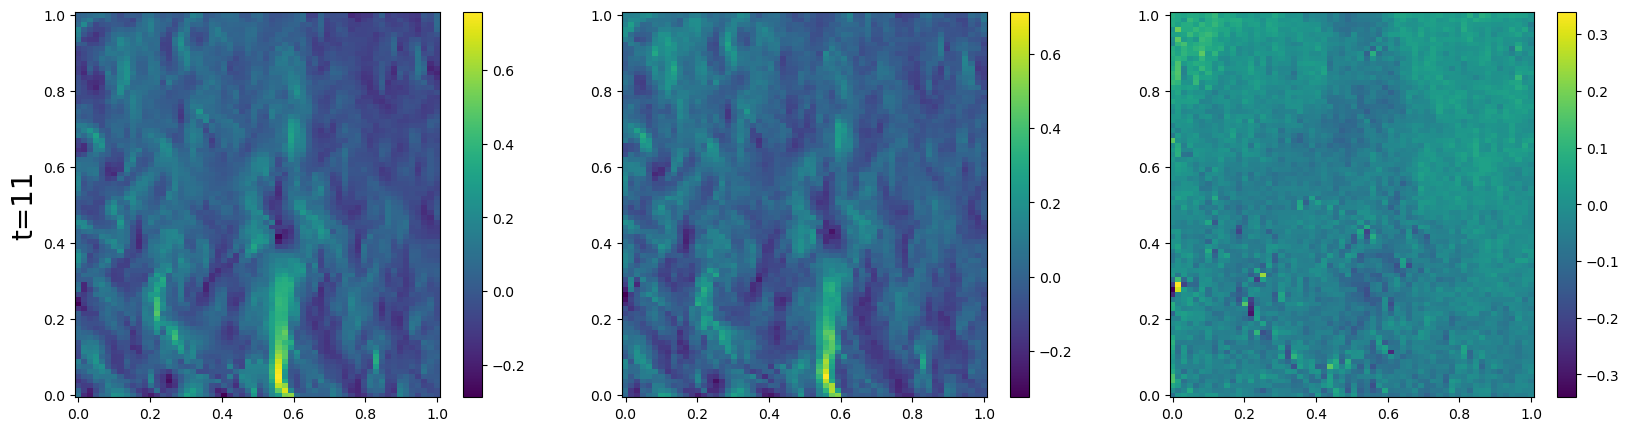

Relative l2 error of u: 5.133e-01
12


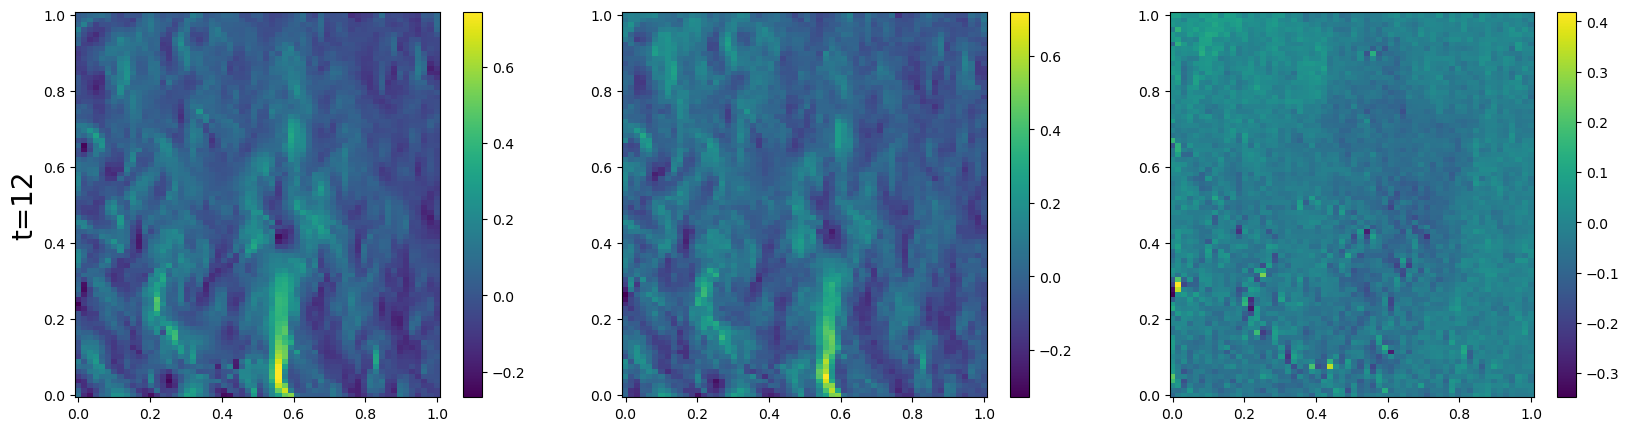

Relative l2 error of u: 5.138e-01
13


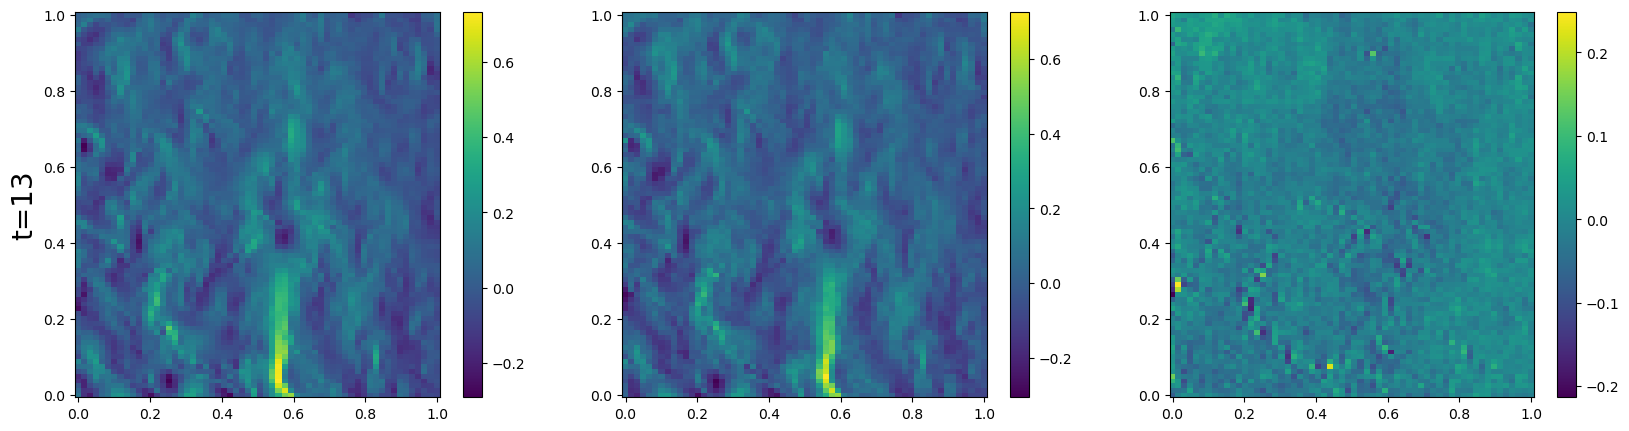

Relative l2 error of u: 3.186e-01
14


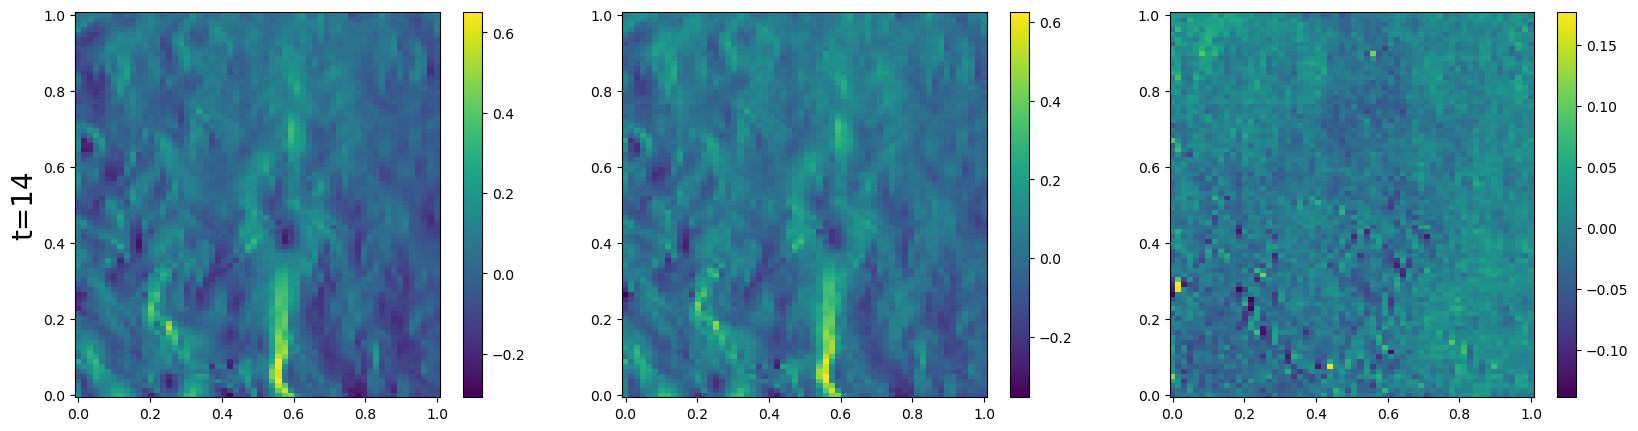

Relative l2 error of u: 2.645e-01
15


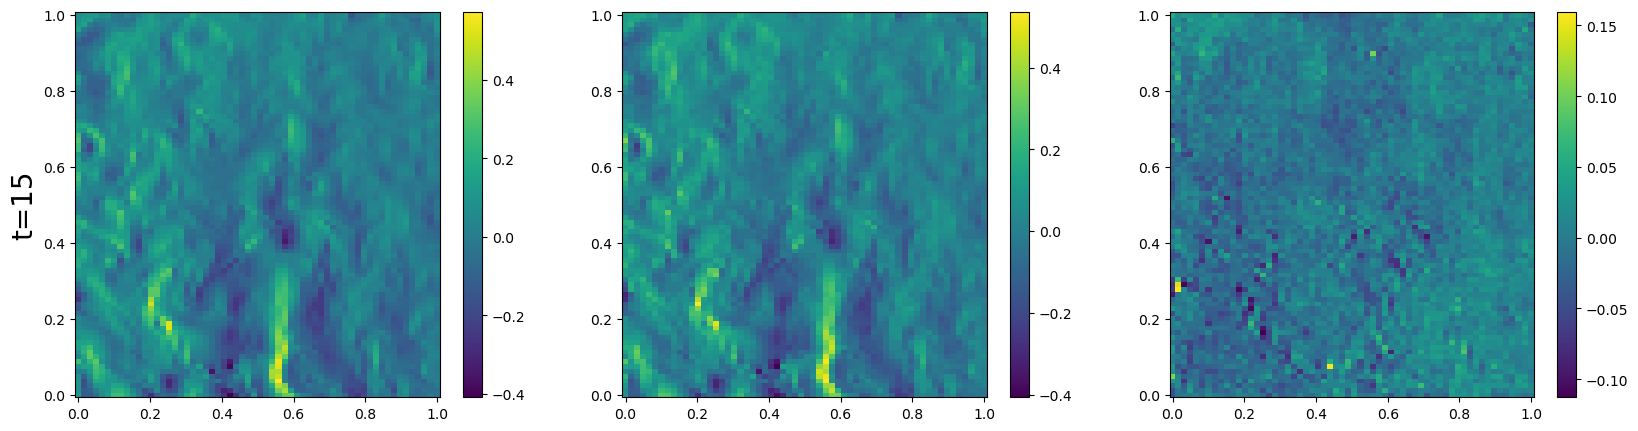

Relative l2 error of u: 2.272e-01
16


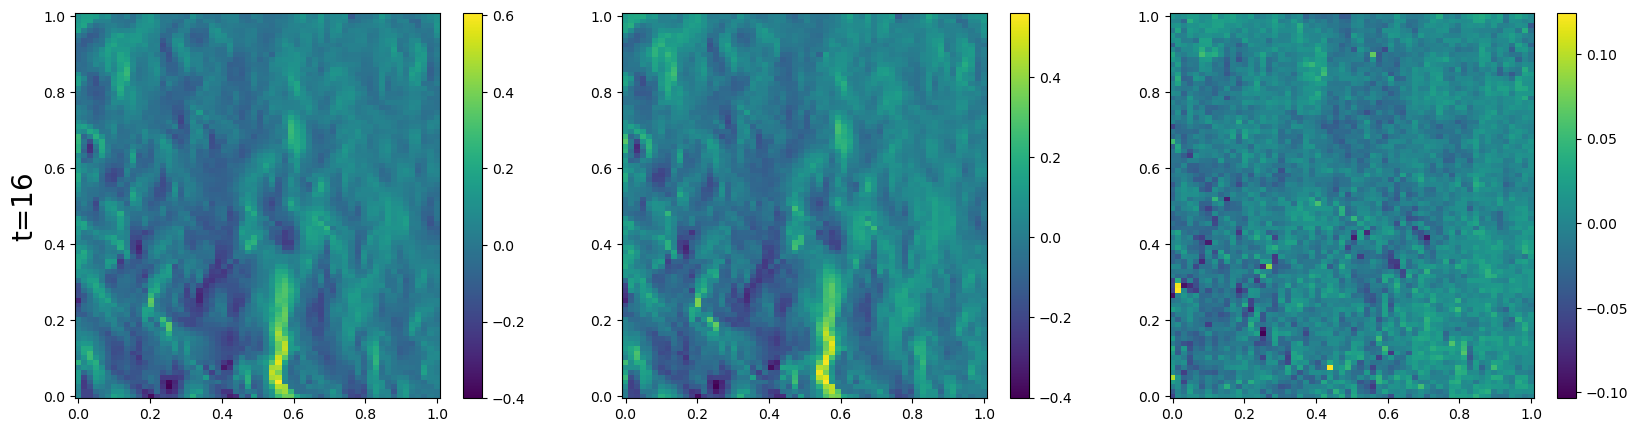

Relative l2 error of u: 1.961e-01
17


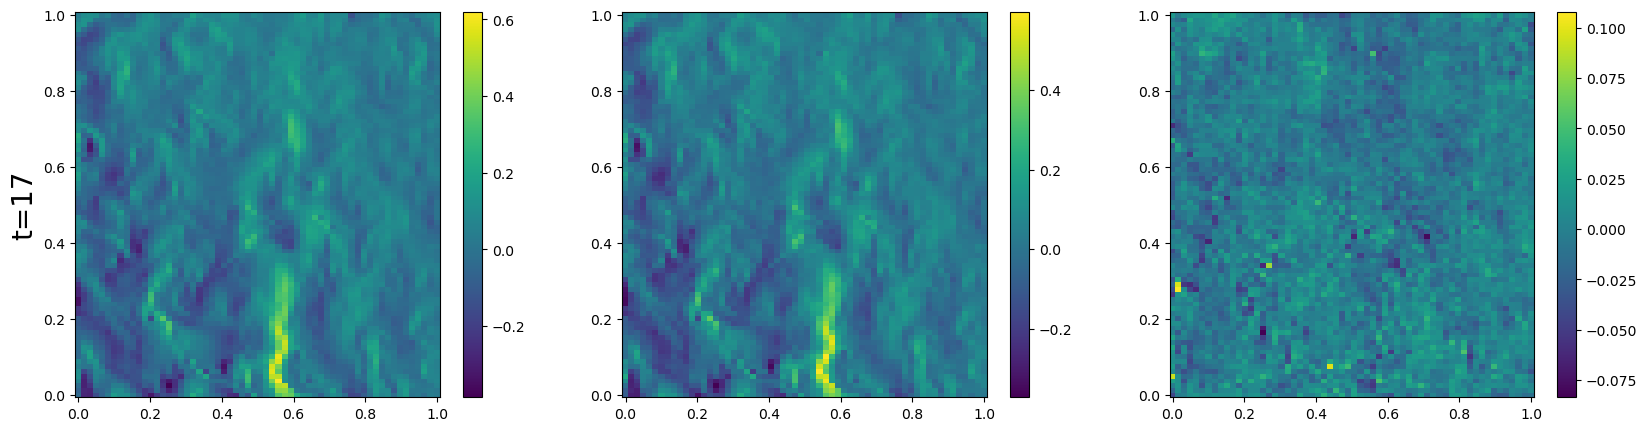

Relative l2 error of u: 1.543e-01
18


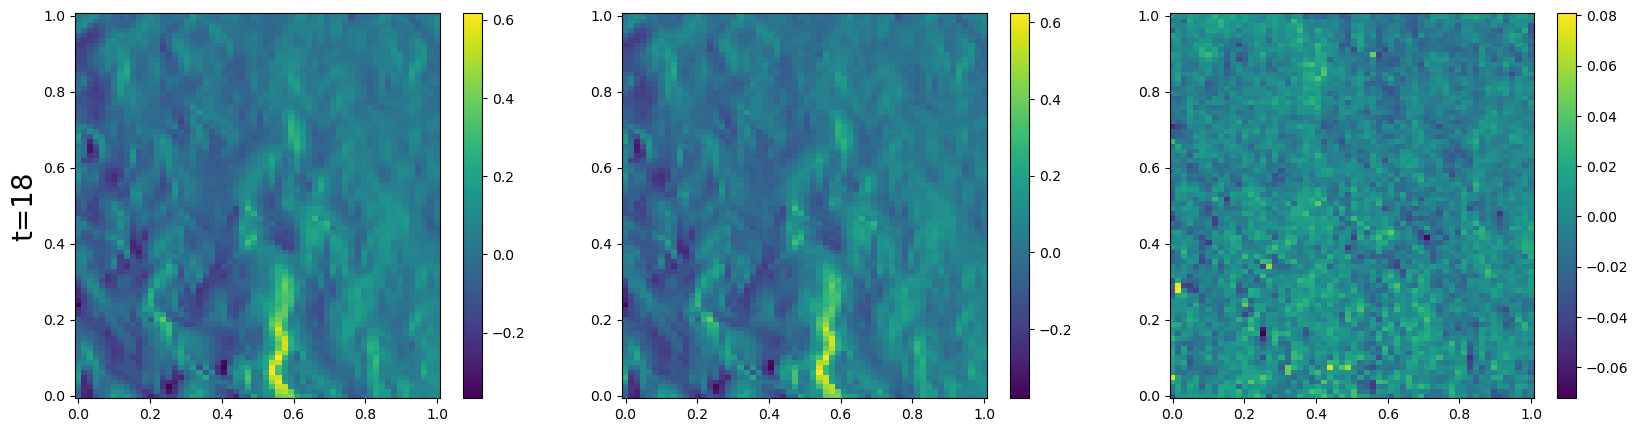

Relative l2 error of u: 1.343e-01
19


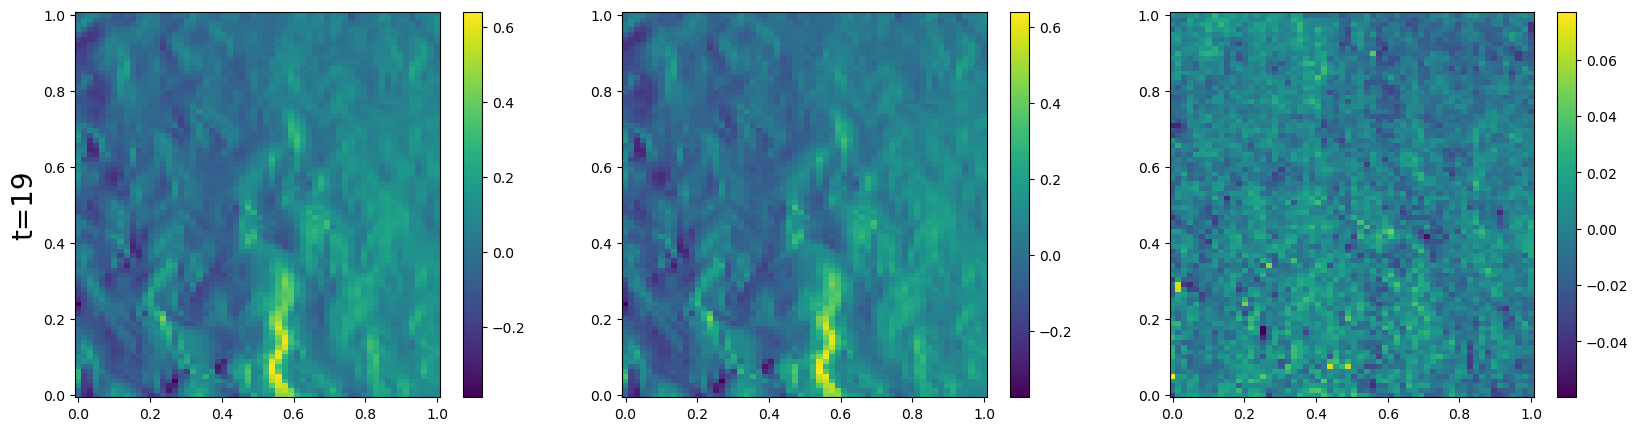

Relative l2 error of u: 1.085e-01
20


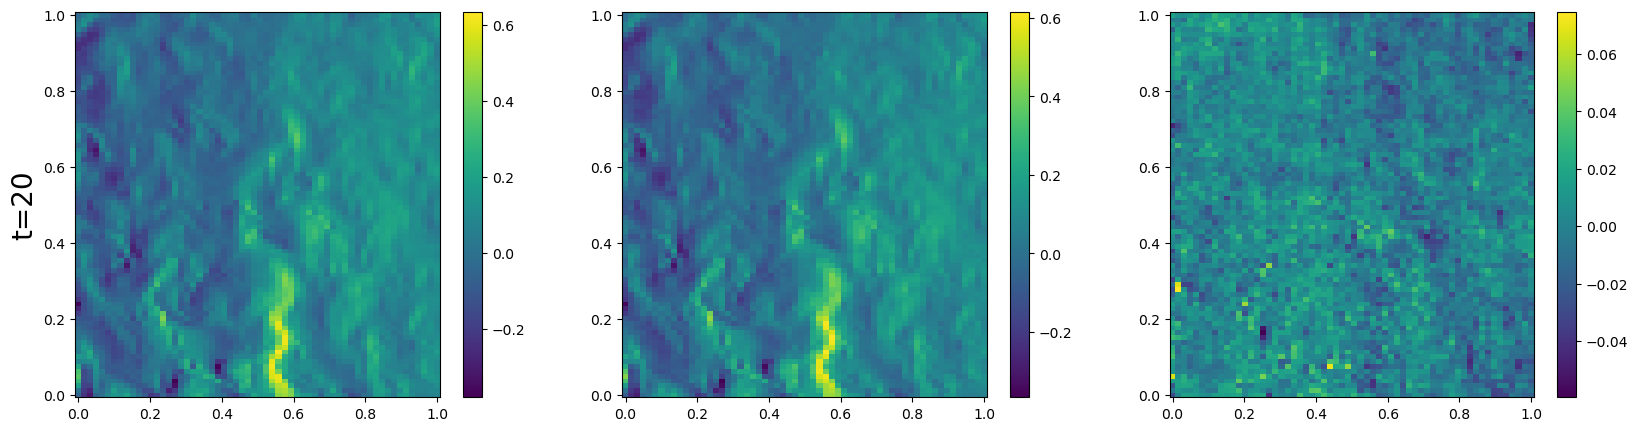

Relative l2 error of u: 1.033e-01
21


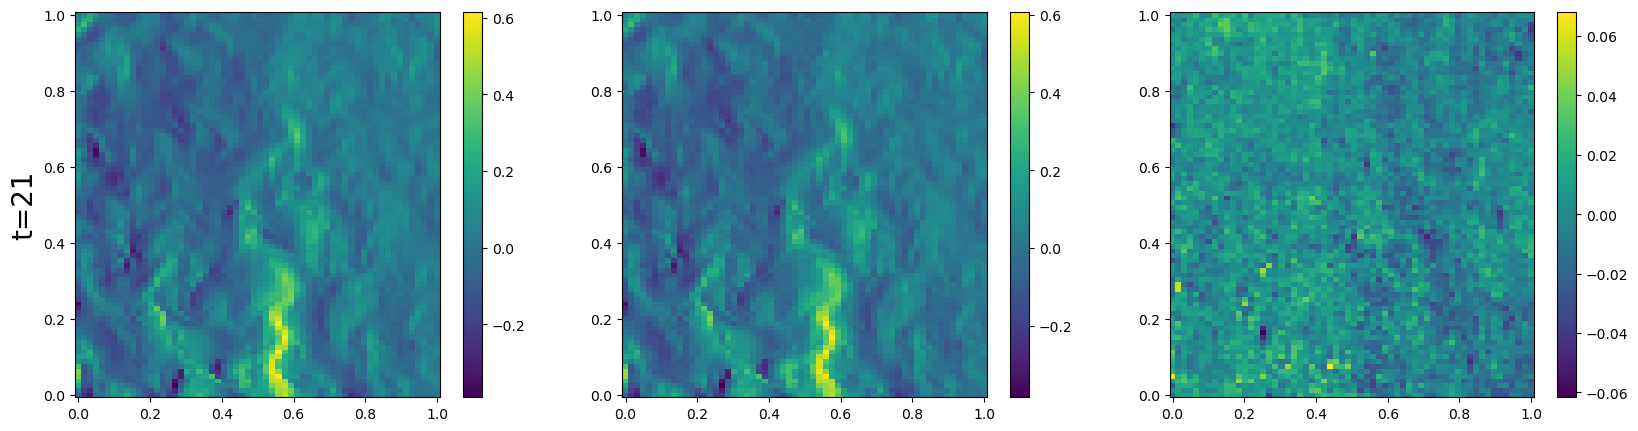

Relative l2 error of u: 1.163e-01
22


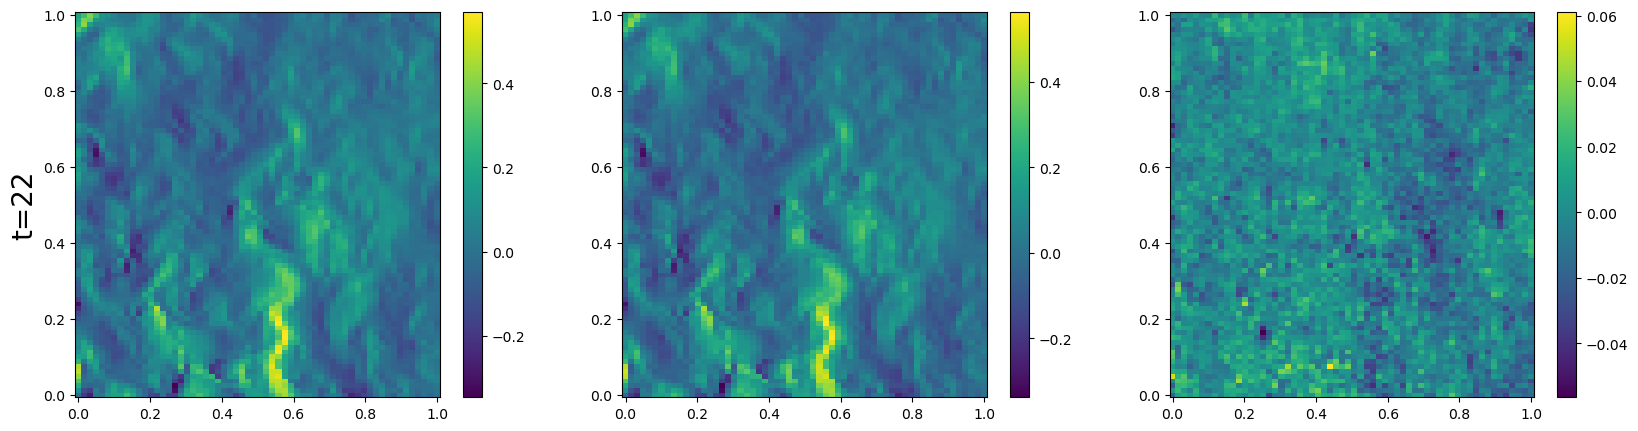

Relative l2 error of u: 1.139e-01
23


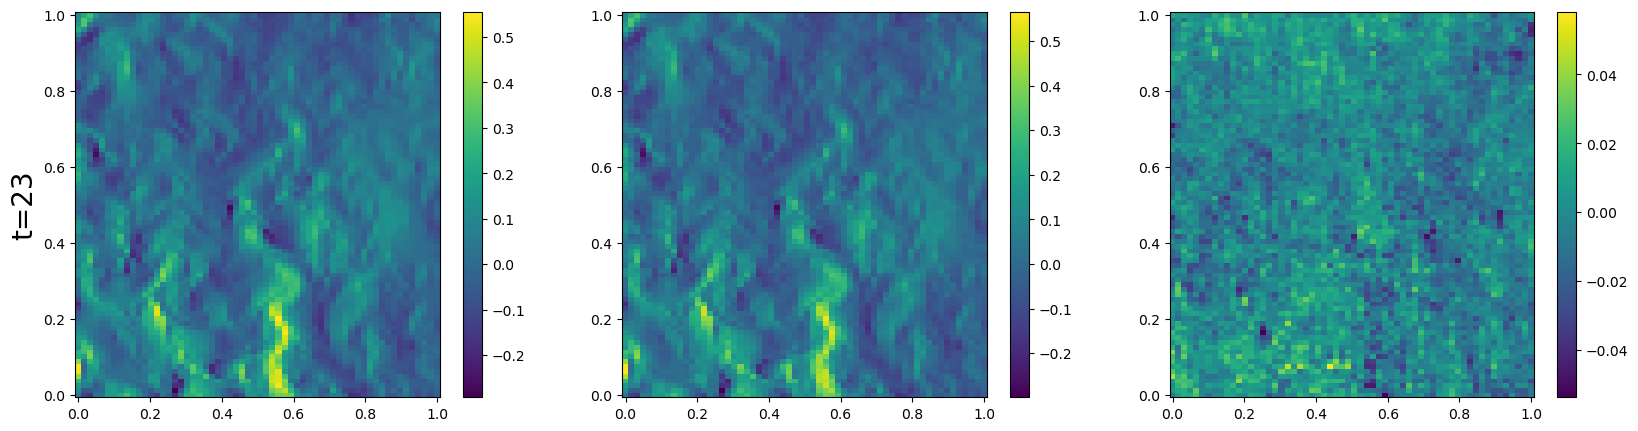

Relative l2 error of u: 1.186e-01
24


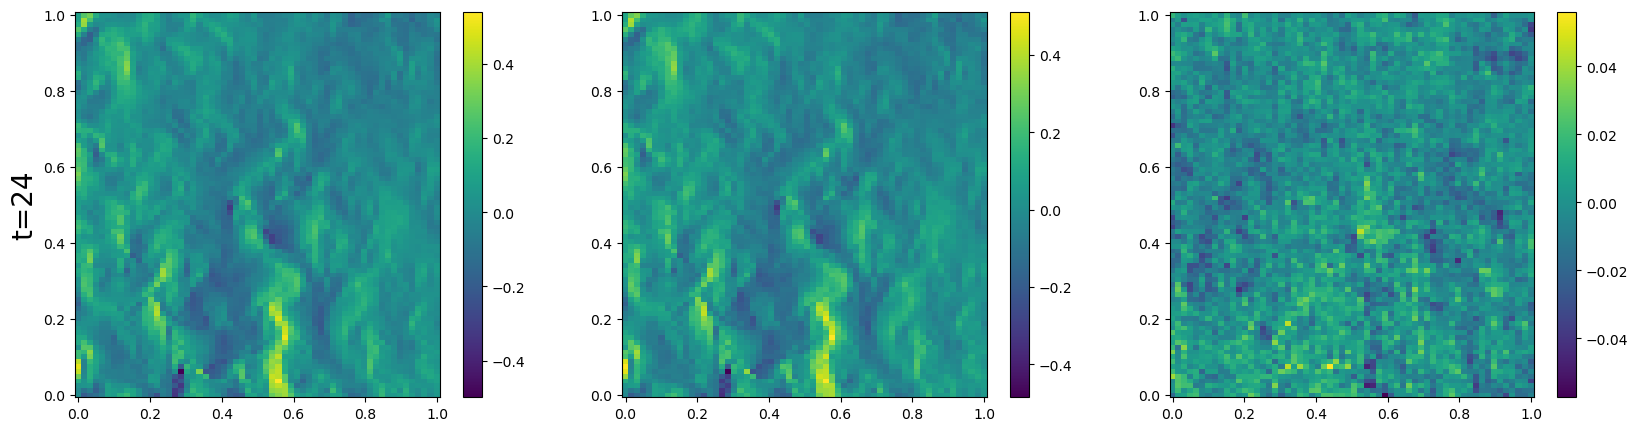

Relative l2 error of u: 1.158e-01
25


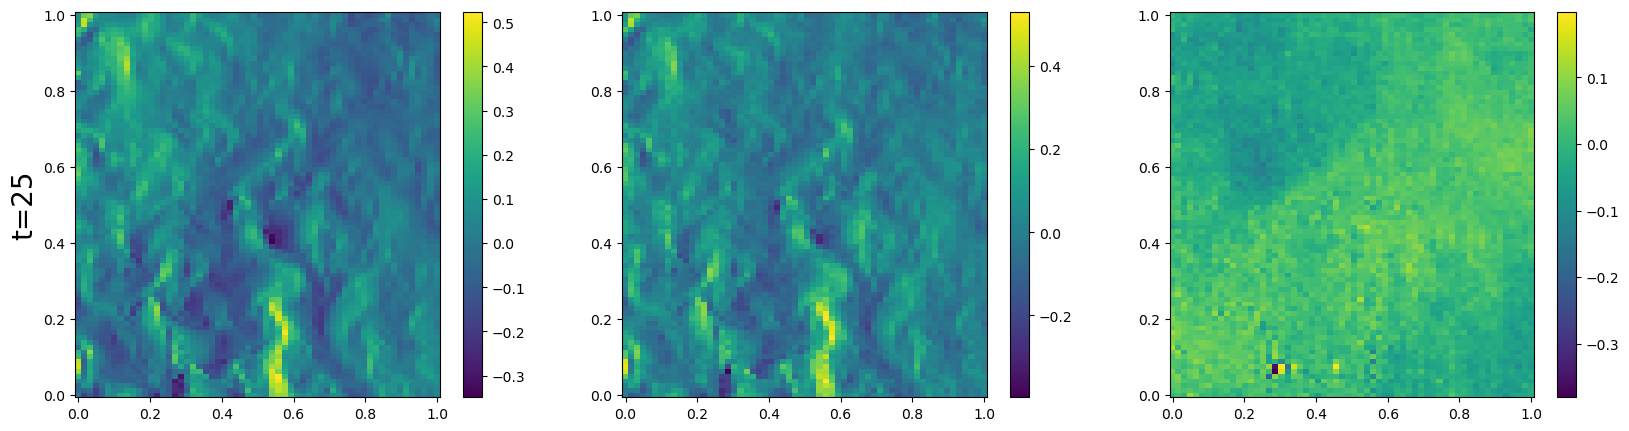

Relative l2 error of u: 4.202e-01
26


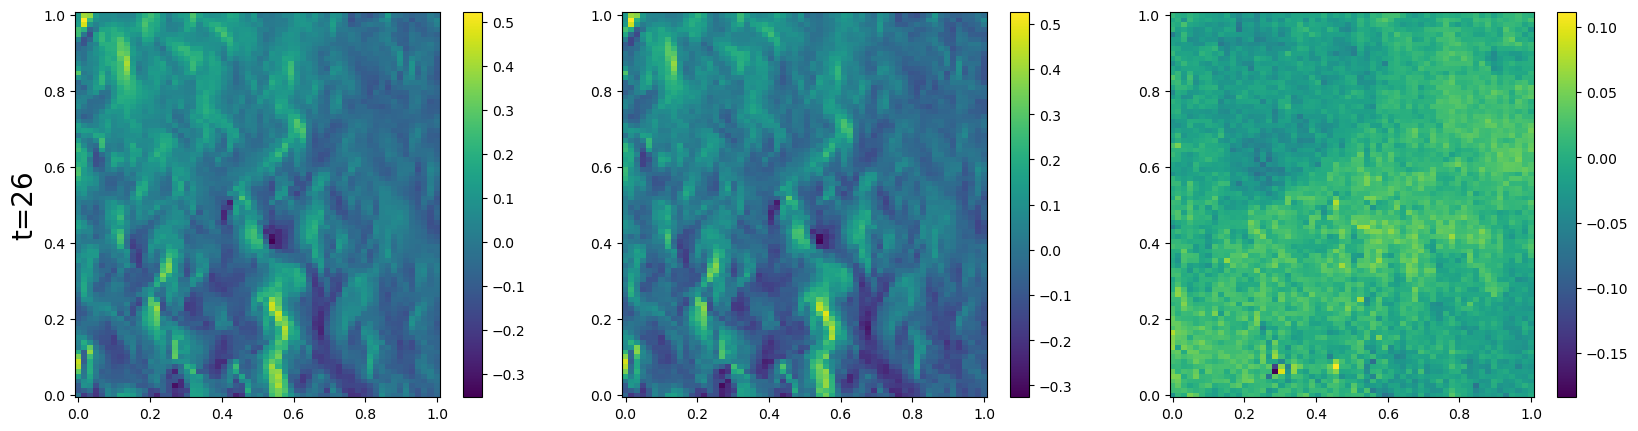

Relative l2 error of u: 2.174e-01
27


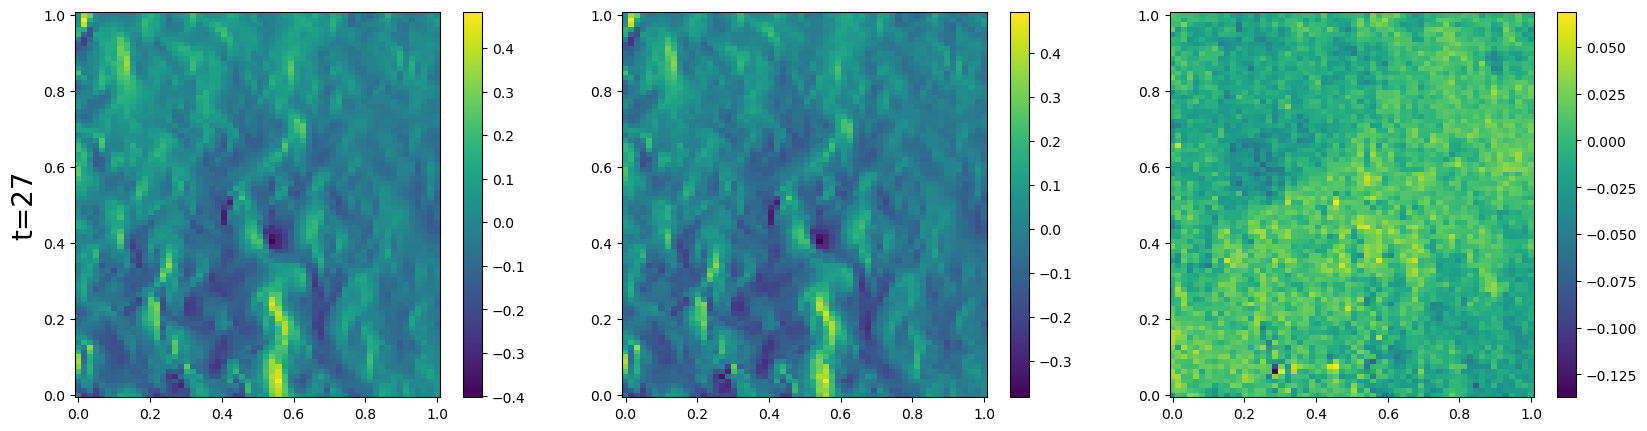

Relative l2 error of u: 1.860e-01
28


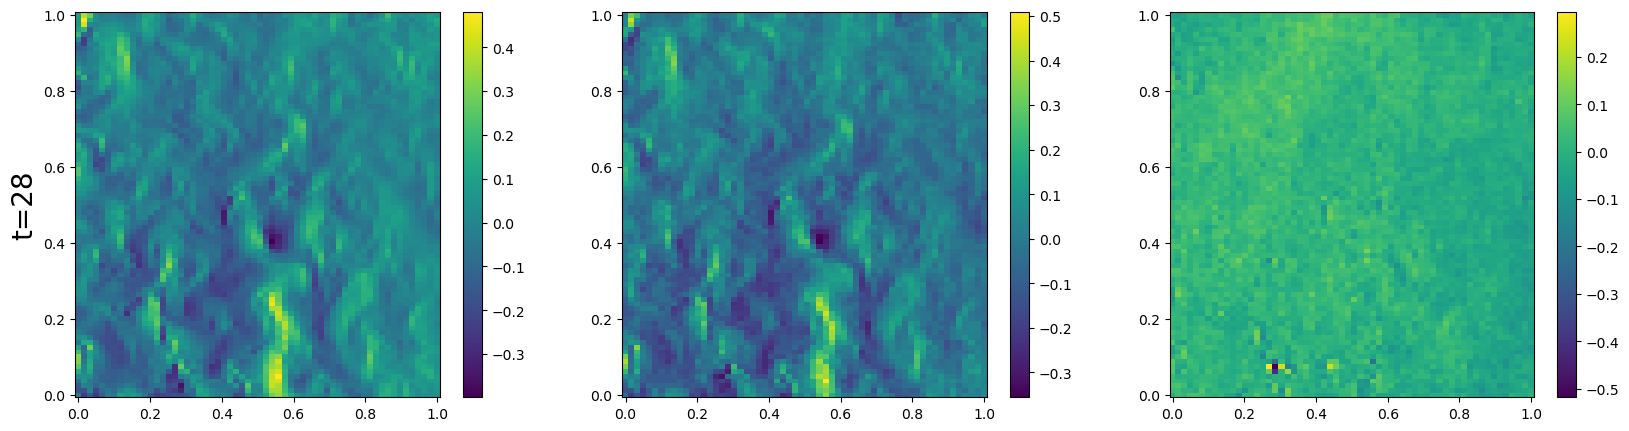

Relative l2 error of u: 4.009e-01
29


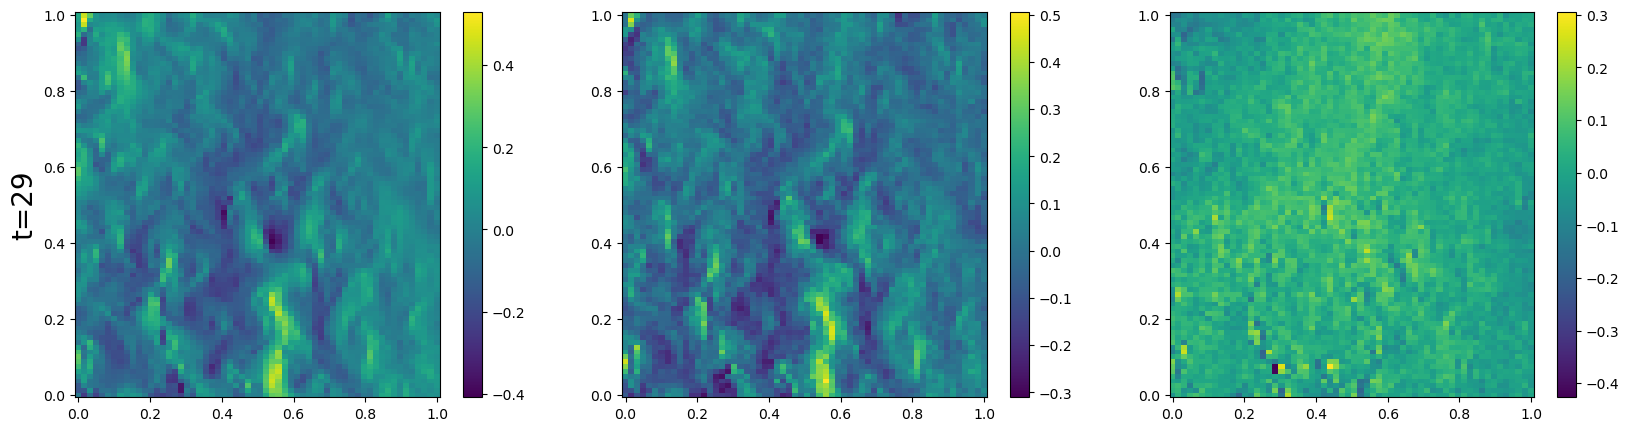

Relative l2 error of u: 5.657e-01
30


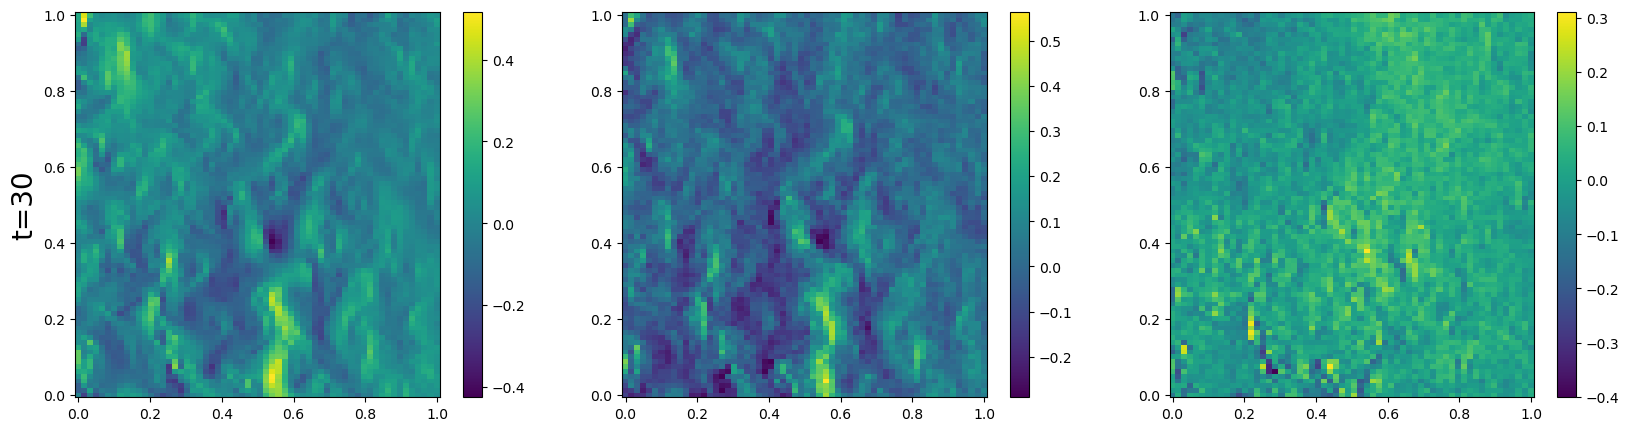

Relative l2 error of u: 6.505e-01
Total relative l2 error of u: 2.043e-01


In [ ]:
import matplotlib.pyplot as plt
# a = np.linspace(0,1,180)
# b = np.linspace(0,1,240)
a = np.linspace(0,1,148)
b = np.linspace(0,1,149)
aa, bb = np.meshgrid(a, b)

error_list = []

# for i in range(10,60,10):
for i in range(infer_steps):
    print(i)
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 3, 1)
    plt.pcolor(aa, bb, y[0,i,:,:,0])
    plt.colorbar()
    plt.ylabel(f't={i}',fontsize=20)

    plt.subplot(1, 3, 2)
    plt.pcolor(aa, bb, y_hat[0,i,:,:,0])
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.pcolor(aa, bb, y_hat[0,i,:,:,0]-y[0,i,:,:,0])
    plt.colorbar()
    plt.show()

    error = np.linalg.norm(y[0,i,:,:,0].flatten() - y_hat[0,i,:,:,0].flatten(),2) / np.linalg.norm(y[0,i,:,:,0].flatten(),2) 
    error_list.append(error)
    print('Relative l2 error of u: {:.3e}'.format(error.mean()))

error = np.array(error_list).reshape(-1, 1)
print('Total relative l2 error of u: {:.3e}'.format(error.mean()))